In [1]:
#Make sure R can find packages installed with Conda
.libPaths('/hb/home/jbos/.conda/envs/vcfR')
.libPaths("/hb/home/jbos/.conda/envs/vcfR/lib/R/library")

In [2]:
#Load packages
library(tidyverse)
library(cowplot)
library(grid)
library(viridis)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp


Loading required package: viridisLite



In [4]:
fsts_chrom7_south<-read.table('/scratch/jbos/Moz_aligned_mil/sfs2_chrom7/grp1vs3.window_fst.txt')
colnames(fsts_chrom7_south)<-c('chrom','midPos','Nsites','FST')

In [5]:
fsts_chrom7_north<-read.table('/scratch/jbos/Moz_aligned_mil/sfs2_chrom7/grp1vs7.window_fst.txt')
colnames(fsts_chrom7_north)<-c('chrom','midPos','Nsites','FST')

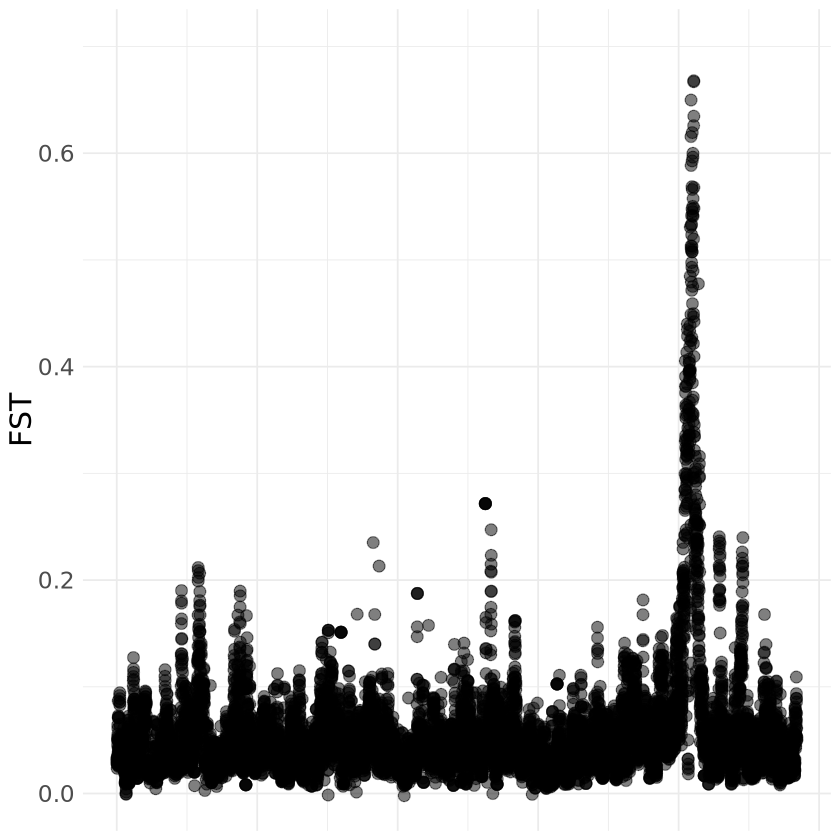

In [37]:
manplt1<-ggplot(data = fsts_chrom7_north, aes(x = midPos, y = FST)) +
  geom_point(size = 3, alpha = 0.5, col = "black") +
theme_minimal()+
theme(legend.position = "none")+
coord_cartesian(ylim = c(0, 0.7))+
theme(axis.title = element_text(size = 18),axis.text = element_text(size = 14),axis.title.x=element_blank(),axis.text.x = element_blank())
show(manplt1)

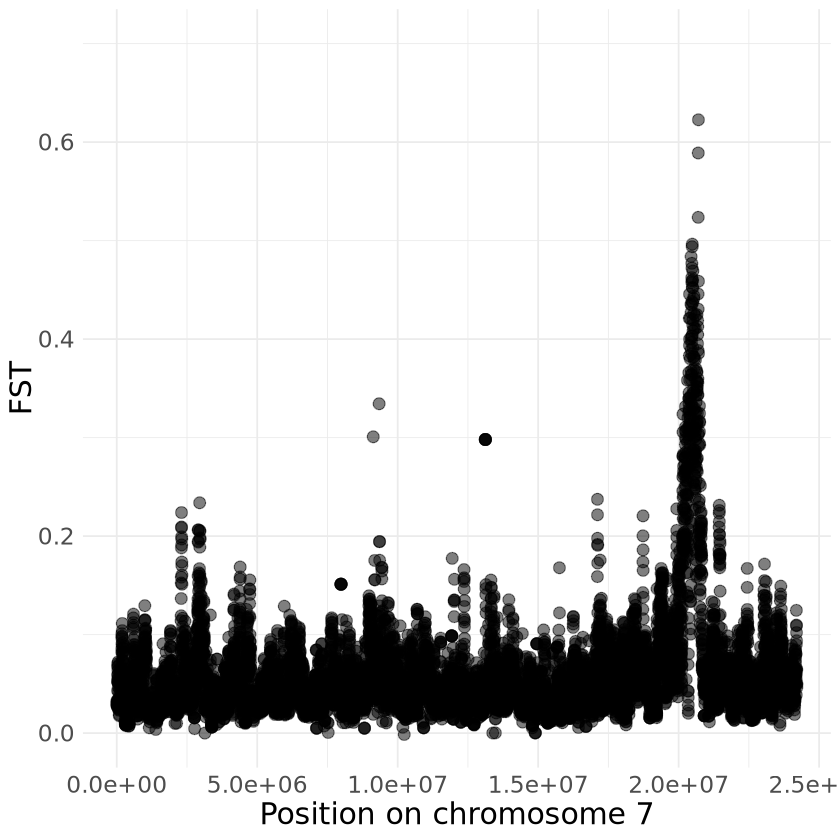

In [40]:
manplt2<-ggplot(data = fsts_chrom7_south, aes(x = midPos, y = FST)) +
  geom_point(size = 3, alpha = 0.5, col = "black") +
coord_cartesian(ylim = c(0, 0.7))+
theme_minimal()+
  xlab("Position on chromosome 7") + 
theme(axis.title = element_text(size = 18),axis.text = element_text(size = 14),legend.position = "none")
show(manplt2)

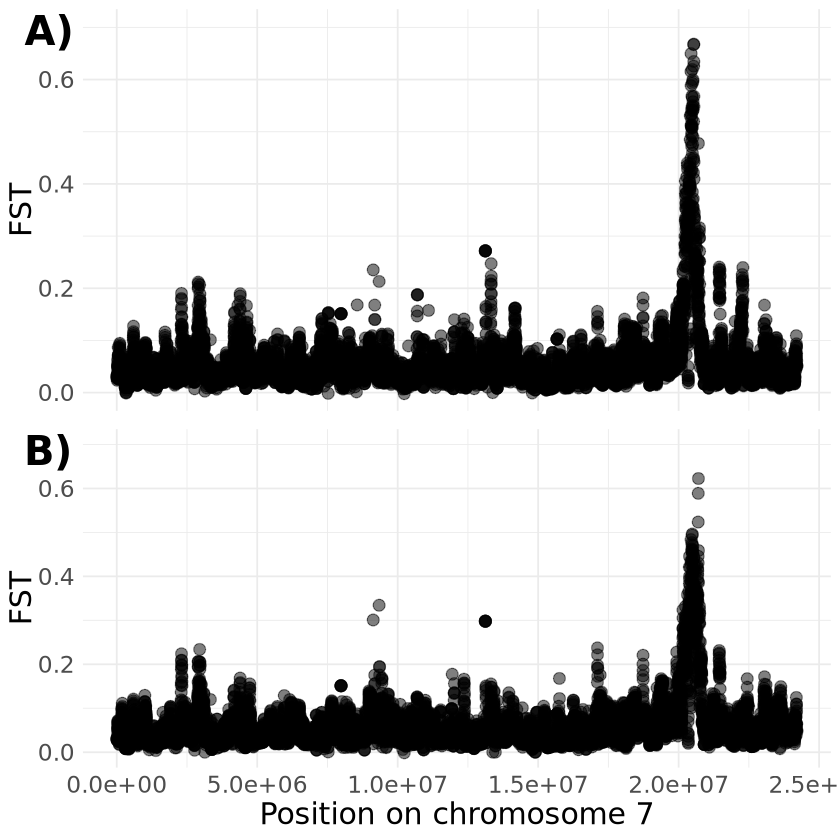

In [43]:
combined <- plot_grid(
  manplt1, manplt2,
  labels = c("A)", "B)"),
  label_size = 24,
  ncol = 1,
  align = "v"
)
show(combined)
# --- Save to file ---
ggsave("Adivaricata_Supplemental2.png", combined, width = 8, height = 10, dpi = 1200, units = "in")